**Data Collection**


We have this data form kaggle.com AT
 https://www.kaggle.com/datasetsaslanahmedov/walmart-sales-forecast  
 and it's for **Walmart Sales**

***Data Exploration:***



*   The dataset comprises a collection of weekly records from a  Walmart stores, spanning from February 5, 2010, to July 26, 2013. It captures critical economic, environmental, and operational features that provide insights into external factors potentially influencing customer behavior and store performance for sales. The dataset includes variables such as temperature, fuel prices, consumer price index (CPI), unemployment rates, holiday indicators, and promotional markdowns. This data serves as a valuable resource for businesses aiming to understand the impact of external conditions on retail operations and to drive data-informed strategies.






**Data Dictionary**

**📌Store**: Identifies the specific store, focusing the dataset on a single
        location.



**📌Date**: Weekly timestamps covering a three-year period, enabling temporal analysis of trends.



**📌Temperature**: Weekly temperature readings (in Fahrenheit), reflecting seasonal changes from winter to summer.



**📌Fuel_Price**: Weekly fuel prices (in dollars per gallon), indicating transportation cost fluctuations.



**📌MarkDown1–5**: Promotional discount fields.



**📌CPI**: Consumer Price Index values , providing a measure of inflation and economic conditions.



**📌Unemployment**: Local unemployment rates, reflecting economic trends in the store’s region.



**📌IsHoliday**: A binary indicator of holiday weeks, highlighting potential spikes in customer activity.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#print all columns of dataframe
pd.set_option('display.max_columns', None)
#print all data in a feature
pd.set_option('display.max_colwidth', None)

In [ ]:
# Load data
df = pd.read_csv('features.csv')

# Convert Date to datetime and IsHoliday to boolean
df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
df['IsHoliday'].unique()

array([False,  True])

In [ ]:
df.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [ ]:
df.tail()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False
8189,45,2013-07-26,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,False


In [ ]:
# Data overview
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         8190 non-null   int64         
 1   Date          8190 non-null   datetime64[ns]
 2   Temperature   8190 non-null   float64       
 3   Fuel_Price    8190 non-null   float64       
 4   MarkDown1     4032 non-null   float64       
 5   MarkDown2     2921 non-null   float64       
 6   MarkDown3     3613 non-null   float64       
 7   MarkDown4     3464 non-null   float64       
 8   MarkDown5     4050 non-null   float64       
 9   CPI           7605 non-null   float64       
 10  Unemployment  7605 non-null   float64       
 11  IsHoliday     8190 non-null   bool          
dtypes: bool(1), datetime64[ns](1), float64(9), int64(1)
memory usage: 712.0 KB
None


In [ ]:
print(df.isnull().sum())

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


In [ ]:
#Describe numeric values
df.describe()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,2011-10-31 12:00:00,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
min,1.000000,2010-02-05 00:00:00,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,2010-12-17 00:00:00,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,2011-10-31 12:00:00,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,2012-09-14 00:00:00,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,2013-07-26 00:00:00,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000
std,12.987966,NaN,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259


In [ ]:
#Describe categrical values
df[['Store', 'IsHoliday']].describe(include='all')

,Store,IsHoliday
count,8190.000000,8190
unique,NaN,2
top,NaN,False
freq,NaN,7605
mean,23.000000,NaN
std,12.987966,NaN
min,1.000000,NaN
25%,12.000000,NaN
50%,23.000000,NaN
75%,34.000000,NaN


In [ ]:
# check dublicated
print(df.duplicated().sum())

0


***Distribution Analysis***



**We have three types of columns:**    

1.   Numeric columns (Temperature, Fuel_Price, CPI, Unemployment, MarkDown1:5)
2.   Categorical columns (Store, IsHoliday)
3. Date columns (Date)





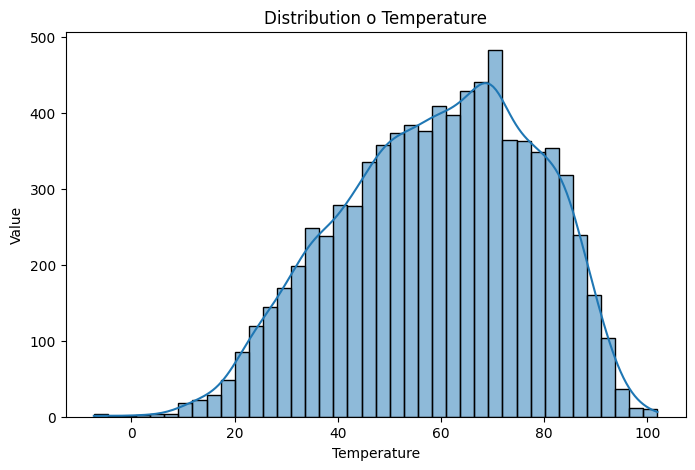

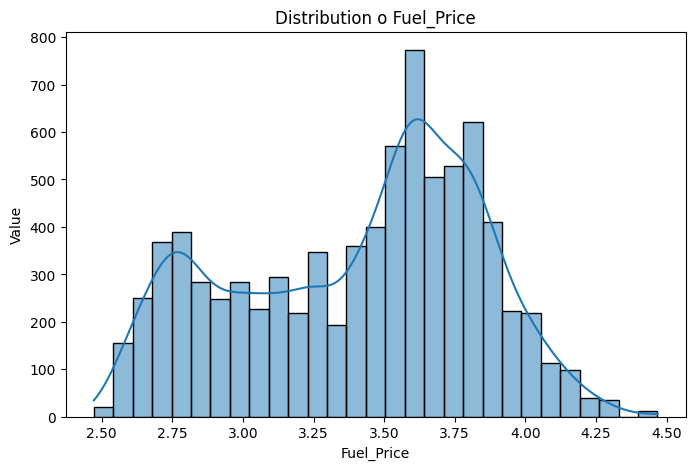

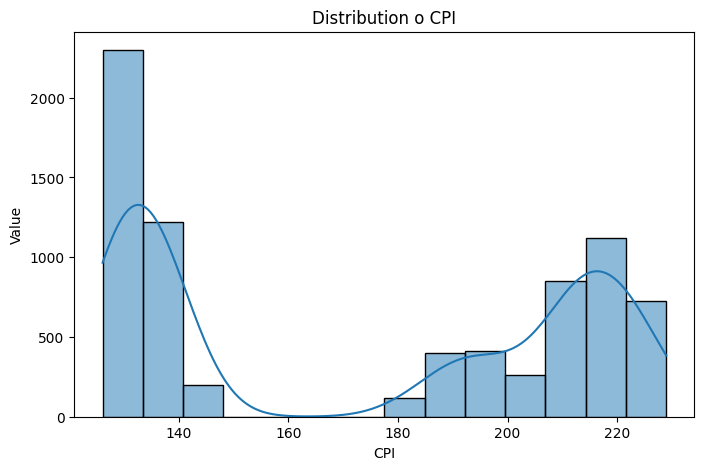

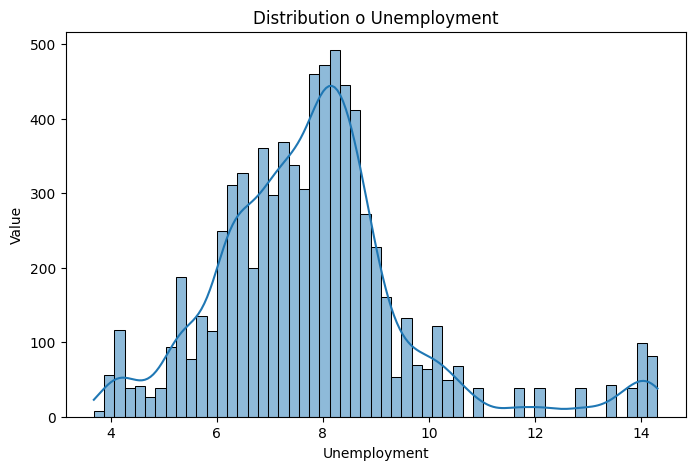

In [ ]:
# Draw Histogram for numeric columns
for col in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']:
    plt.figure(figsize=(8, 5))

    #Drop Nan values to not affect on Hist
    #We use here Kernel denisity esitmate to soft the distribution
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution o {col}')
    plt.xlabel(col)
    plt.ylabel('Value')
    plt.show()

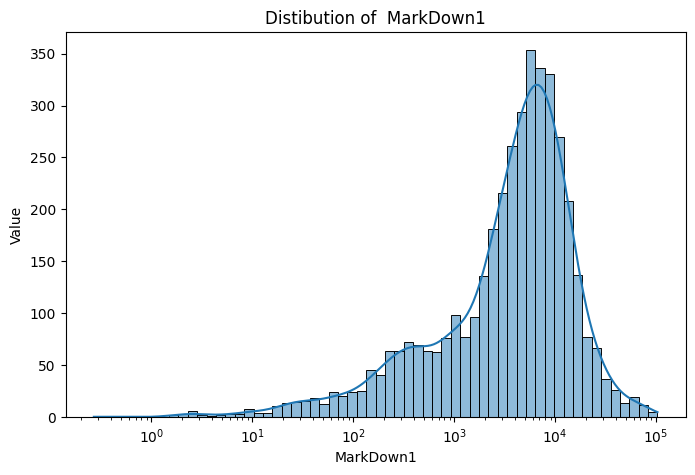

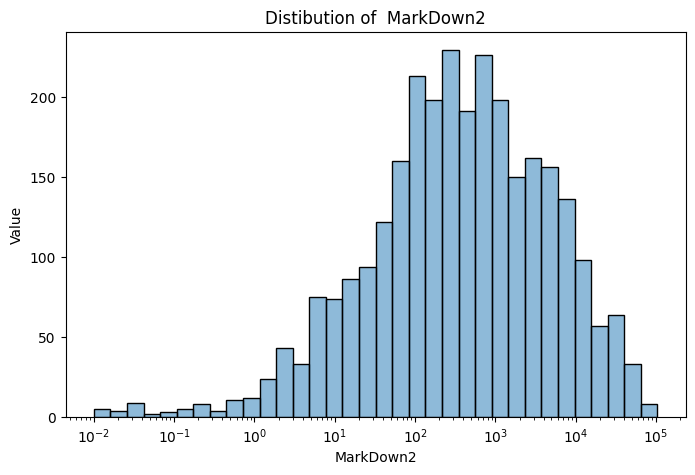

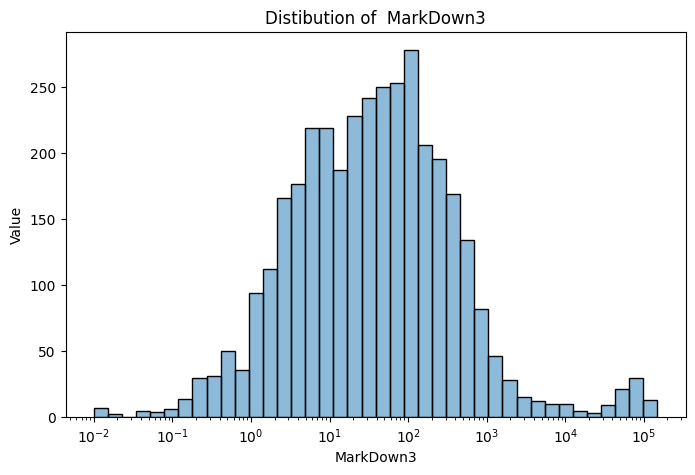

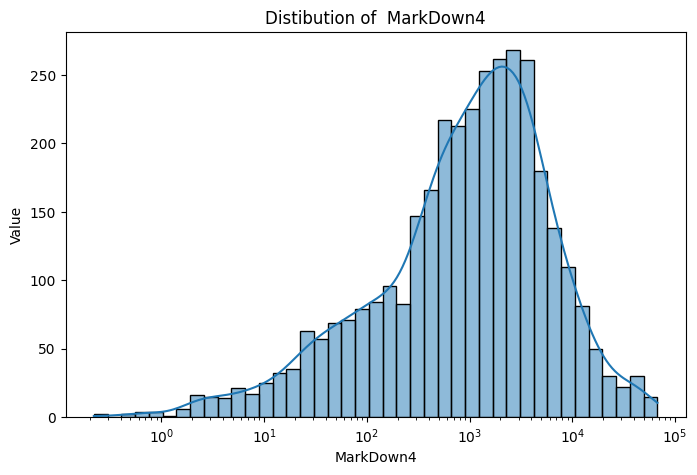

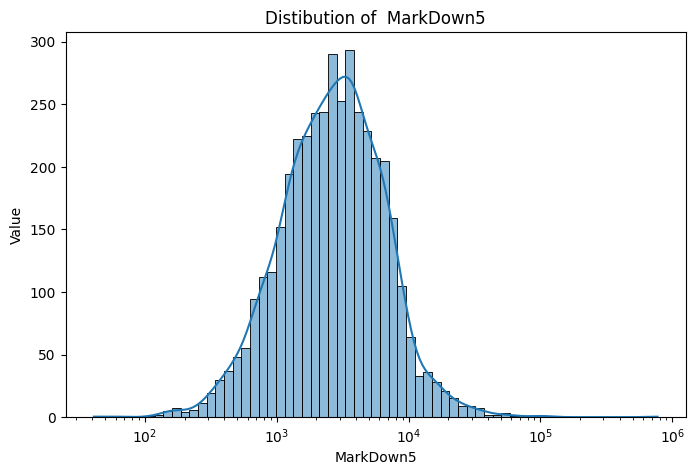

In [ ]:
#Draw special numeric columns
for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
  plt.figure(figsize=(8, 5))

  #convert the regular linear scale into log scale for x, y axes due to Values is ditributed unequaly or have a big differencies
  sns.histplot(df[col].dropna(), kde=True, log_scale=True) #if col is zero or negative value it will throw an error
  plt.title(f'Distibution of  {col}')
  plt.xlabel(col)
  plt.ylabel('Value')
  plt.show()

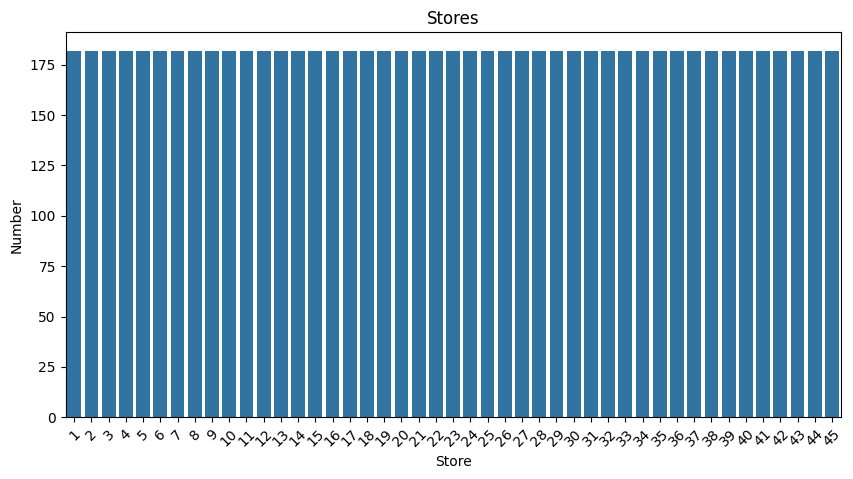

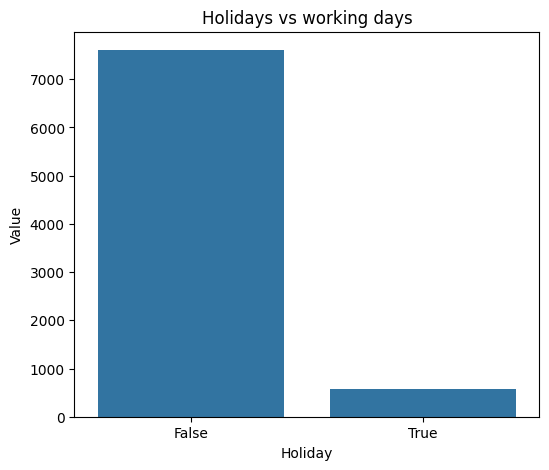

In [ ]:
#Plot Categrical columns
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Store')
plt.title('Stores')
plt.xticks(rotation=45)
plt.xlabel('Store')
plt.ylabel('Number')
plt.show()

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='IsHoliday')
plt.title('Holidays vs working days')
plt.xlabel('Holiday')
plt.ylabel('Value')
plt.show()

In [ ]:
colors = ["#F9BD10", "#289947"]
explode = [0.05, 0.05]


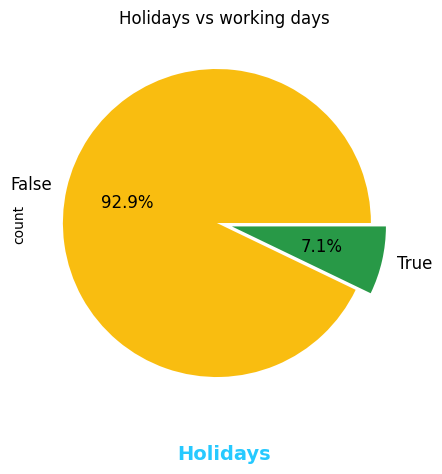

In [ ]:
#Draw a pie chart for IsHoliday coulmn
plt.figure(figsize=(6, 5))
counts = df['IsHoliday'].value_counts()
counts.plot(kind = 'pie', fontsize = 12, explode = explode, autopct = '%1.1f%%', colors = colors)
plt.xlabel('Holidays', weight = "bold", color = "#26C9FF", fontsize = 14, labelpad = 20)
plt.title('Holidays vs working days')
plt.show()

In [ ]:
df['Store'].value_counts()

,count
Store,
1,182
2,182
3,182
4,182
5,182
6,182
7,182
8,182
9,182


***OUTLIEARS DETICTION***




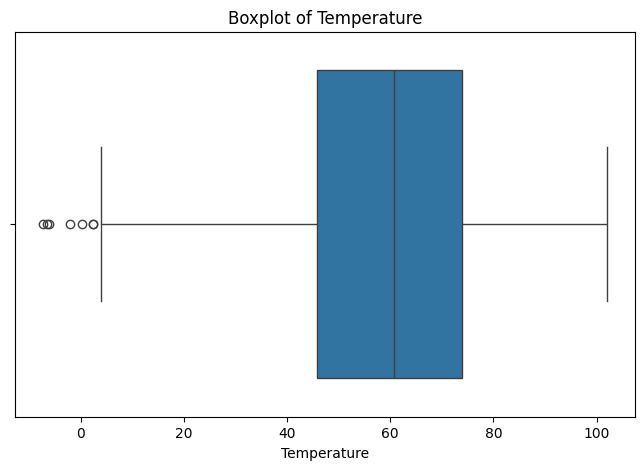

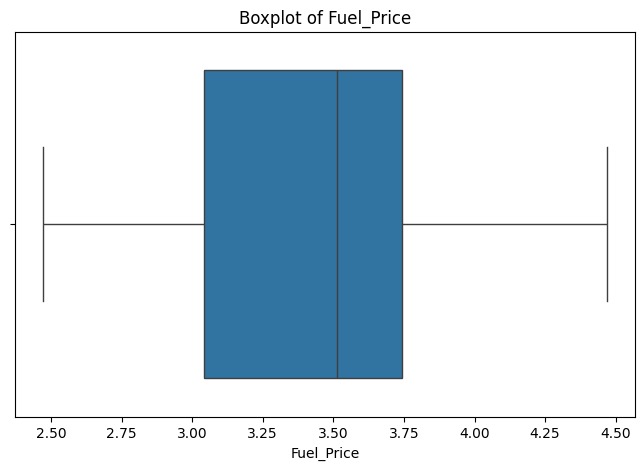

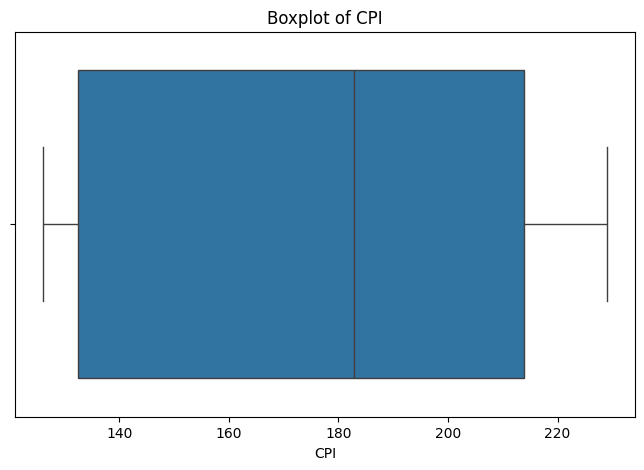

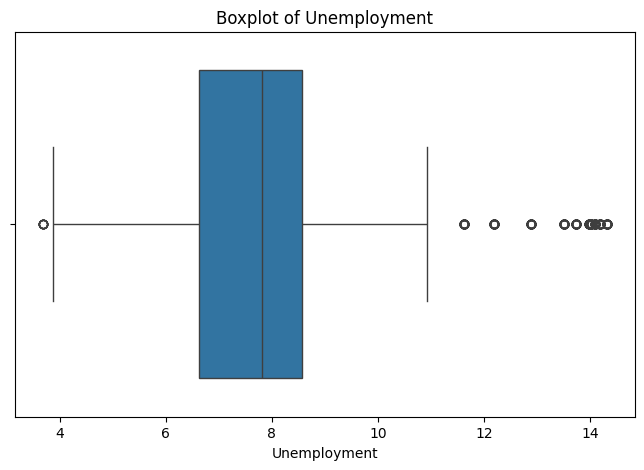

In [ ]:
# Outlier detection for Temperature, Fuel_Price, CPI, Unemployment
for col in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

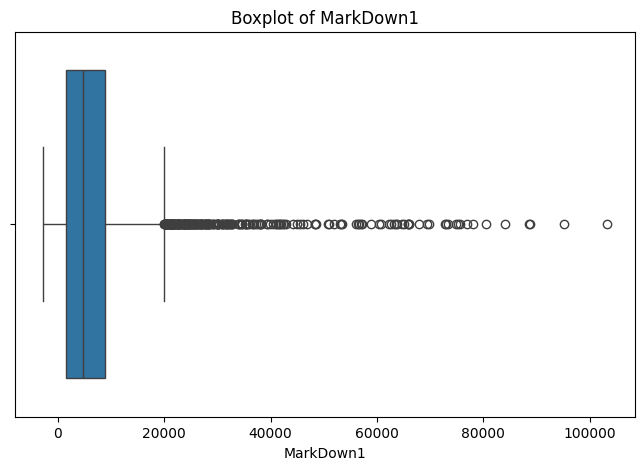

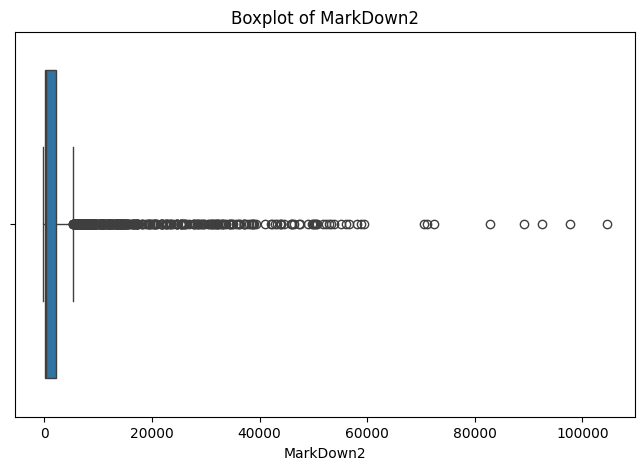

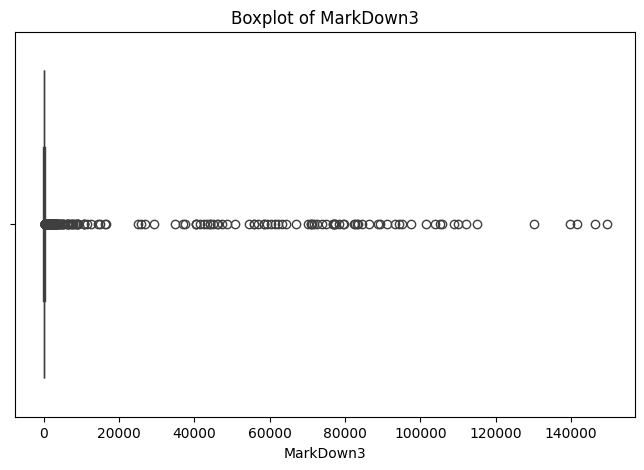

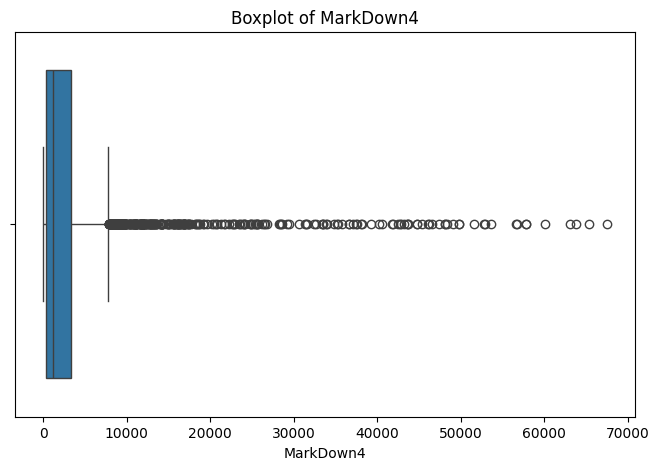

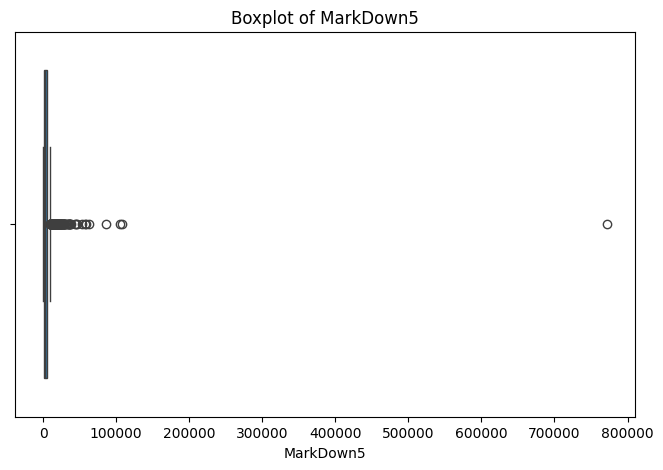

In [ ]:
# Outlier detection for MarkDown1–5 (non-NAN values)
for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.show()

***Handle NAN values***

In [ ]:
# Impute NA values in MarkDown1–5 with 0
for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
    df[col].fillna(0, inplace=True)  # Replace NA with 0

<ipython-input-44-8d24d4afa74d>:3: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
df['MarkDown1']

,MarkDown1
0,0.00
1,0.00
2,0.00
3,0.00
4,0.00
...,...
8185,4842.29
8186,9090.48
8187,3789.94
8188,2961.49


In [ ]:
# Impute NAN values in CPI with forward-fill within each Store
df['CPI'] = df.groupby('Store')['CPI'].fillna(method='ffill')

<ipython-input-46-8014ac2c8e91>:2: FutureWarning:

SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead

<ipython-input-46-8014ac2c8e91>:2: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [ ]:
df['CPI']

,CPI
0,211.096358
1,211.242170
2,211.289143
3,211.319643
4,211.350143
...,...
8185,193.589304
8186,193.589304
8187,193.589304
8188,193.589304


In [ ]:
print(df['CPI'].isnull().sum())

0


In [ ]:
#Impute Unemployment column with forward-fill method
df['Unemployment'] = df.groupby('Store')['Unemployment'].fillna(method='ffill')

<ipython-input-49-956c758ca425>:2: FutureWarning:

SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead

<ipython-input-49-956c758ca425>:2: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [ ]:
df['Unemployment']

,Unemployment
0,8.106
1,8.106
2,8.106
3,8.106
4,8.106
...,...
8185,8.335
8186,8.335
8187,8.335
8188,8.335


In [ ]:
#check null in dataset
print(df.isnull().sum())

Store           0
Date            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday       0
dtype: int64


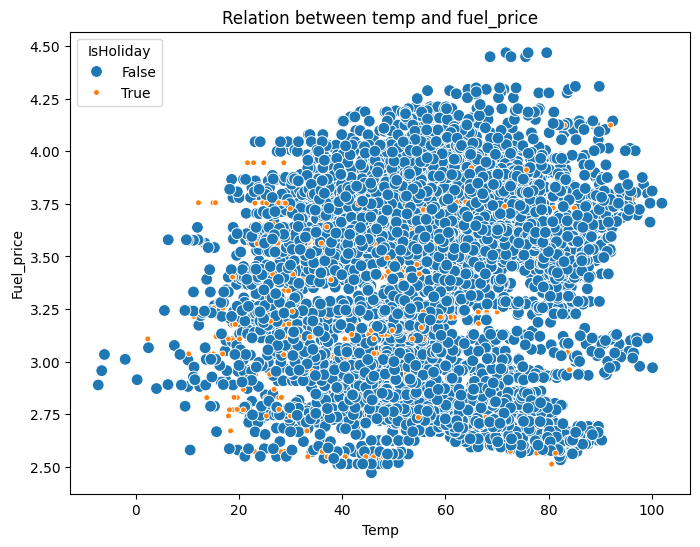

In [ ]:
# Scatter Plot 1: Temperature vs. Fuel_Price
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Temperature', y='Fuel_Price', hue='IsHoliday', size='IsHoliday')
plt.title('Relation between temp and fuel_price')
plt.xlabel('Temp')
plt.ylabel('Fuel_price')
plt.show()

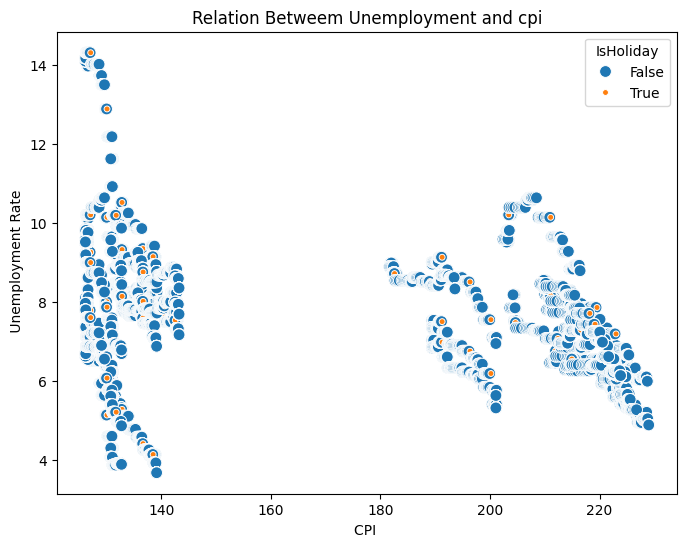

In [ ]:
# Scatter Plot 2: CPI vs. Unemployment
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='CPI', y='Unemployment', hue='IsHoliday', size='IsHoliday')
plt.title('Relation Betweem Unemployment and cpi')
plt.xlabel('CPI ')
plt.ylabel(' Unemployment Rate')
plt.show()

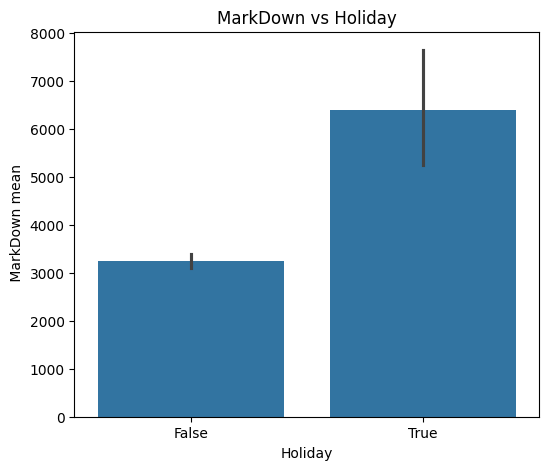

In [ ]:
# Bar Plot 1: Average MarkDown1 by IsHoliday
plt.figure(figsize=(6, 5))
sns.barplot(data=df, x='IsHoliday', y='MarkDown1', estimator='mean')
plt.title('MarkDown vs Holiday')
plt.xlabel('Holiday')
plt.ylabel(' MarkDown mean')
plt.show()

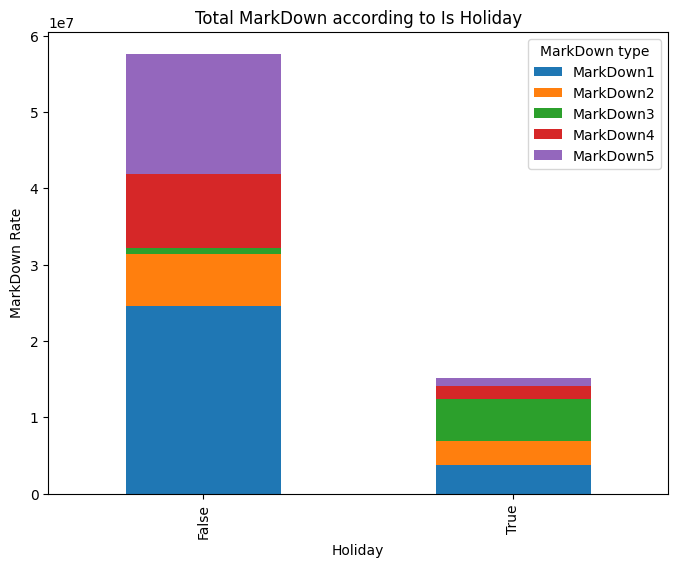

In [ ]:
# Stacked Bar Chart: MarkDown1:5 by IsHoliday
markdown_sums = df.groupby('IsHoliday')[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']].sum()
markdown_sums.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Total MarkDown according to Is Holiday')
plt.xlabel('Holiday')
plt.ylabel('MarkDown Rate')
plt.legend(title='MarkDown type')
plt.show()

***Correlation Analysis***

In [ ]:
# Select numeric columns for correlation analysis
numeric_cols = ['Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment']
correlation_matrix = df[numeric_cols].corr()

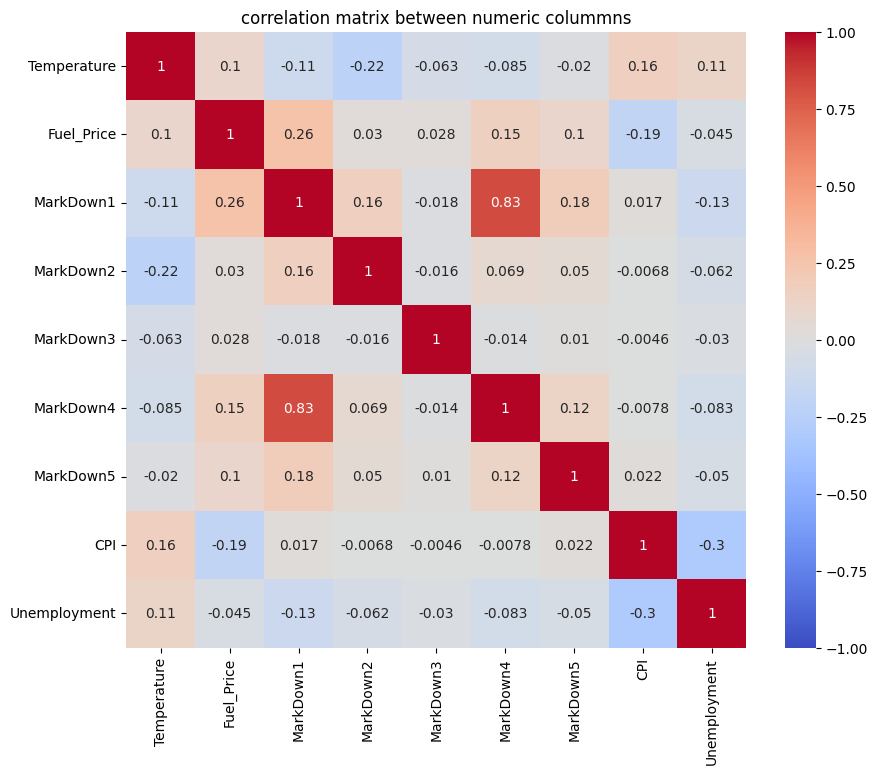

In [ ]:
# Plot correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('correlation matrix between numeric colummns')
plt.show()

In [ ]:
# print correlation matrix as a text for reference
print(correlation_matrix)

              Temperature  Fuel_Price  MarkDown1  MarkDown2  MarkDown3  \
Temperature      1.000000    0.101354  -0.114759  -0.220157  -0.062782   
Fuel_Price       0.101354    1.000000   0.262974   0.030076   0.028349   
MarkDown1       -0.114759    0.262974   1.000000   0.157191  -0.018466   
MarkDown2       -0.220157    0.030076   0.157191   1.000000  -0.016411   
MarkDown3       -0.062782    0.028349  -0.018466  -0.016411   1.000000   
MarkDown4       -0.084683    0.148889   0.826422   0.068612  -0.014163   
MarkDown5       -0.019703    0.100203   0.178319   0.049990   0.010083   
CPI              0.163409   -0.188407   0.016541  -0.006813  -0.004615   
Unemployment     0.114643   -0.045154  -0.132158  -0.061518  -0.029710   

              MarkDown4  MarkDown5       CPI  Unemployment  
Temperature   -0.084683  -0.019703  0.163409      0.114643  
Fuel_Price     0.148889   0.100203 -0.188407     -0.045154  
MarkDown1      0.826422   0.178319  0.016541     -0.132158  
MarkDown2      

***Time Series Analysis***

In [ ]:
# set date as index for time series analysis
df.set_index('Date', inplace=True)

In [ ]:
df.head(20)

,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
Date,,,,,,,,,,,
2010-02-05,1,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False
2010-02-12,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,True
2010-02-19,1,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,False
2010-02-26,1,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,False
2010-03-05,1,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,False
2010-03-12,1,57.79,2.667,0.0,0.0,0.0,0.0,0.0,211.380643,8.106,False
2010-03-19,1,54.58,2.720,0.0,0.0,0.0,0.0,0.0,211.215635,8.106,False
2010-03-26,1,51.45,2.732,0.0,0.0,0.0,0.0,0.0,211.018042,8.106,False
2010-04-02,1,62.27,2.719,0.0,0.0,0.0,0.0,0.0,210.820450,7.808,False


In [ ]:
# Resample to monthly averages for smoother trends
monthly_df = df.resample('ME').mean()

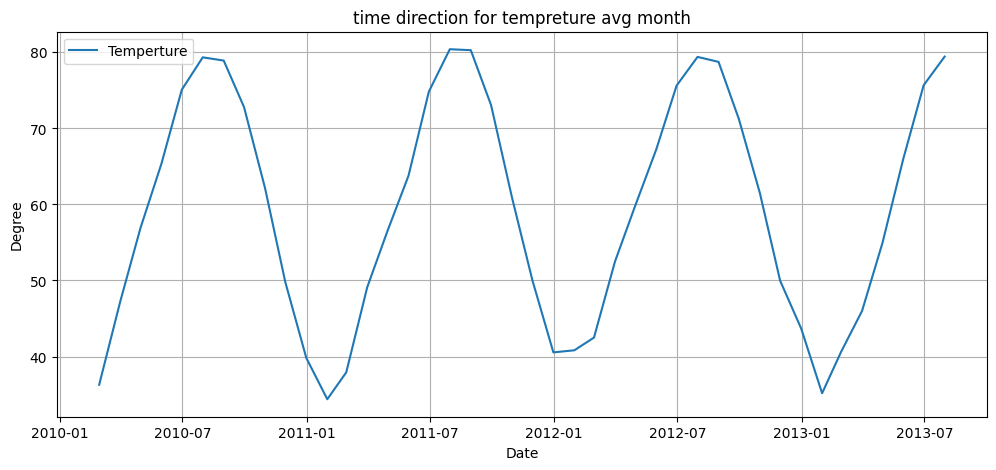

In [ ]:
# Plot time series for Temperature
plt.figure(figsize=(12, 5))
plt.plot(monthly_df.index, monthly_df['Temperature'], label='Temperture')
plt.title('time direction for tempreture avg month')
plt.xlabel('Date')
plt.ylabel('Degree')
plt.legend()
plt.grid(True)
plt.show()

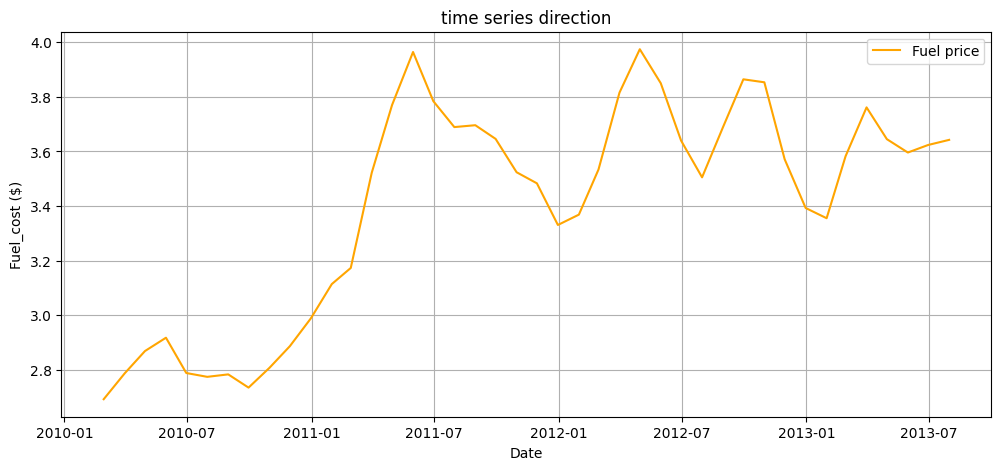

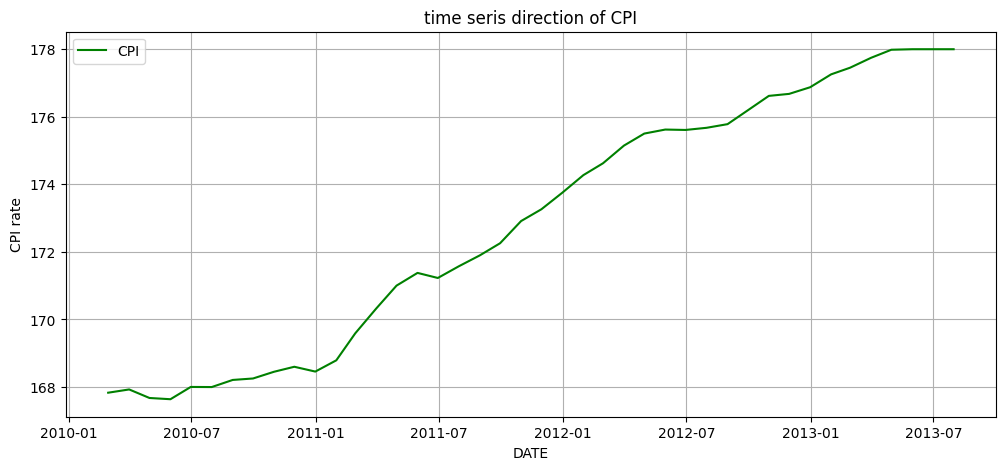

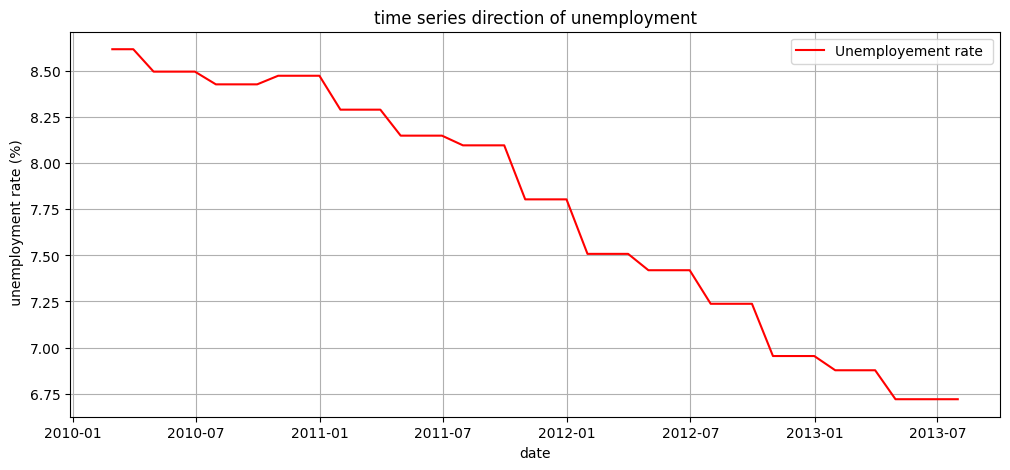

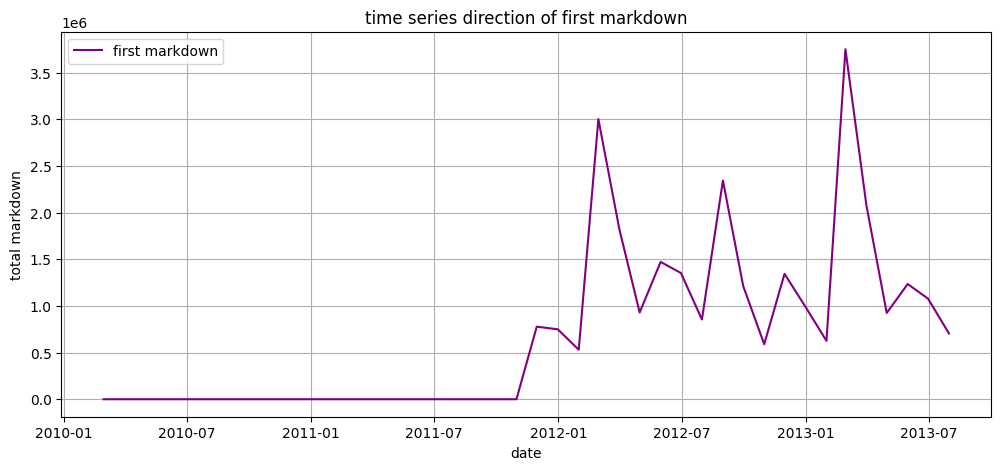

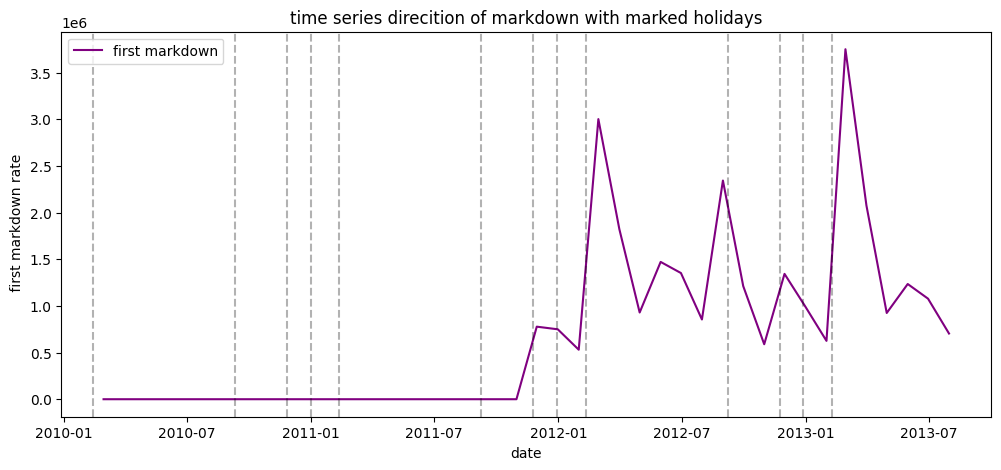

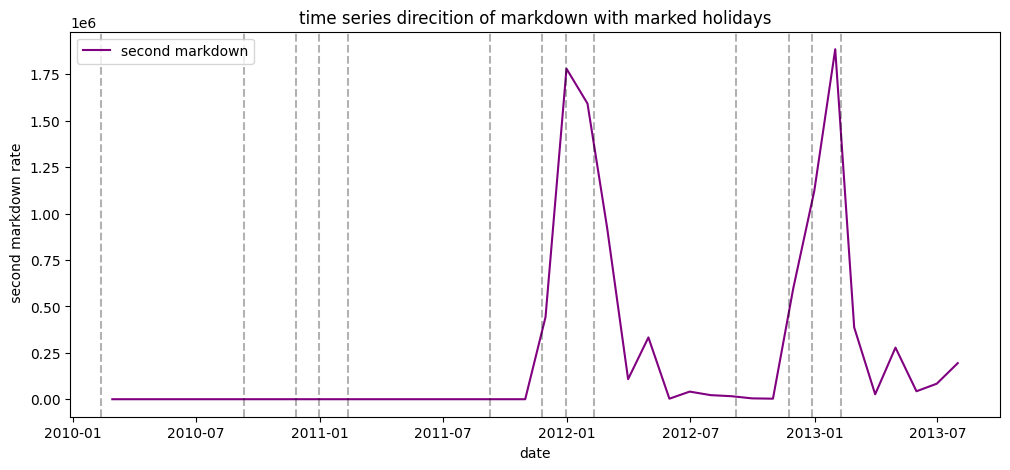

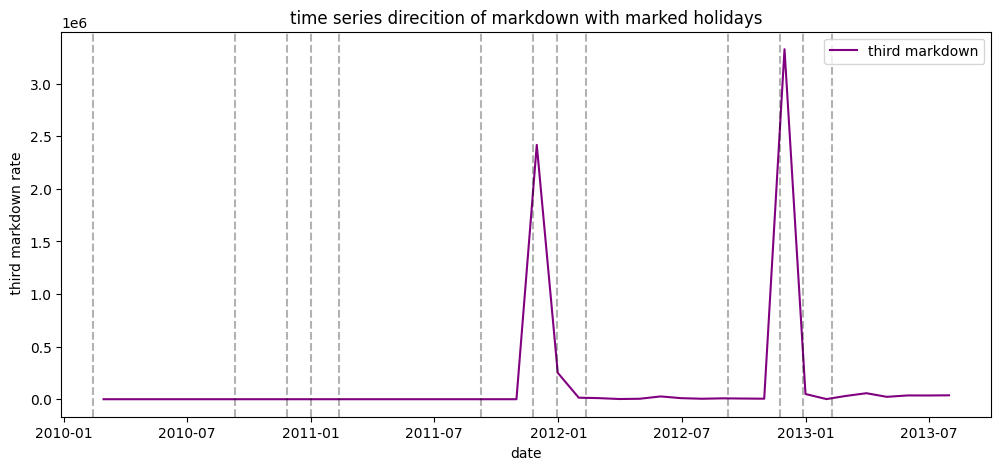

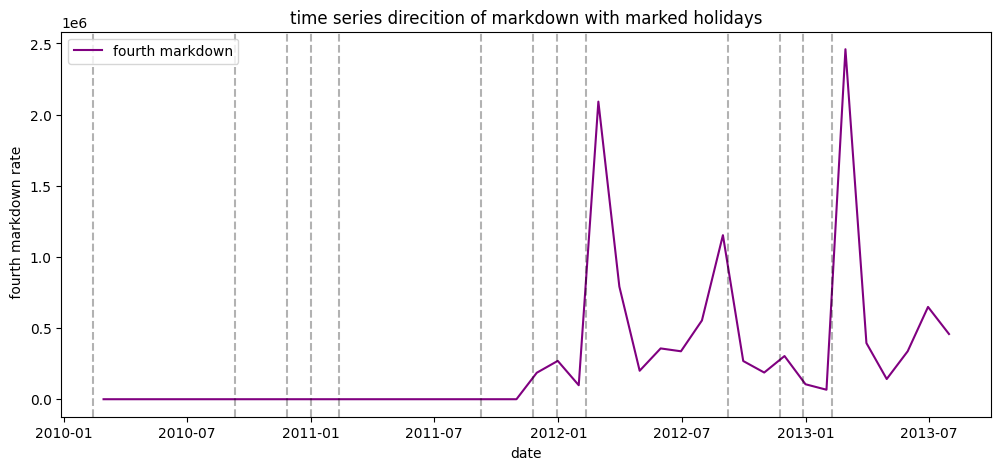

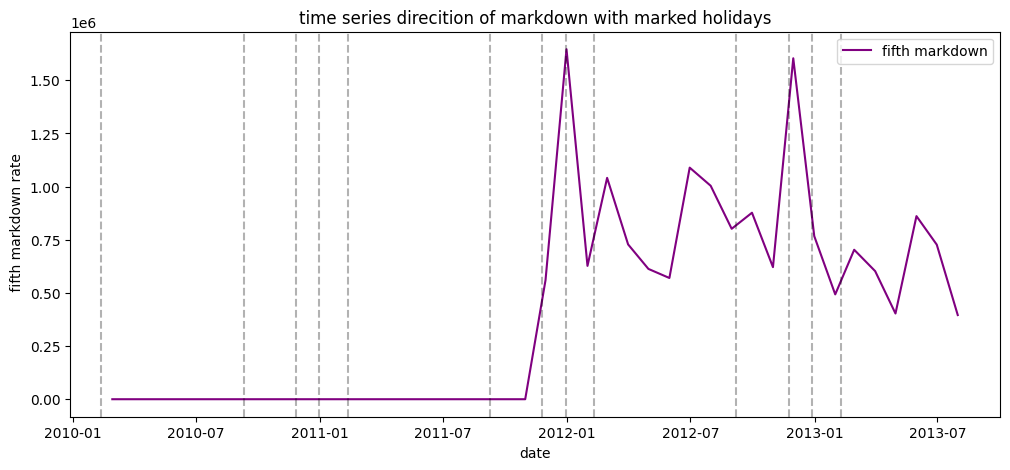

In [ ]:
# Plot time series for Fuel_Price
plt.figure(figsize=(12, 5))
plt.plot(monthly_df.index, monthly_df['Fuel_Price'], label='Fuel price', color='orange')
plt.title('time series direction')
plt.xlabel('Date')
plt.ylabel('Fuel_cost ($)')
plt.legend()
plt.grid(True)
plt.show()

# Plot time series for CPI
plt.figure(figsize=(12, 5))
plt.plot(monthly_df.index, monthly_df['CPI'], label='CPI', color='green')
plt.title('time seris direction of CPI')
plt.xlabel('DATE')
plt.ylabel('CPI rate')
plt.legend()
plt.grid(True)
plt.show()

# Plot time series for Unemployment
plt.figure(figsize=(12, 5))
plt.plot(monthly_df.index, monthly_df['Unemployment'], label='Unemployement rate ', color='red')
plt.title('time series direction of unemployment')
plt.xlabel('date')
plt.ylabel(' unemployment rate (%)')
plt.legend()
plt.grid(True)
plt.show()

# Plot time series for MarkDown1 (sum to capture promotional activity)
monthly_markdown_sum = df[['MarkDown1']].resample('ME').sum()
plt.figure(figsize=(12, 5))
plt.plot(monthly_markdown_sum.index, monthly_markdown_sum['MarkDown1'], label='first markdown', color='purple')
plt.title('time series direction of first markdown')
plt.xlabel('date')
plt.ylabel('total markdown')
plt.legend()
plt.grid(True)
plt.show()

# Highlight holidays in MarkDown1 time series
holiday_dates = df[df['IsHoliday'] == True].index.unique()
plt.figure(figsize=(12, 5))
plt.plot(monthly_markdown_sum.index, monthly_markdown_sum['MarkDown1'], label='first markdown', color='purple')
for holiday in holiday_dates:
    plt.axvline(x=holiday, color='black', linestyle='--', alpha=0.3) #Draw a vertical line On Holiday
plt.title('time series direcition of markdown with marked holidays')
plt.xlabel('date')
plt.ylabel(' first markdown rate')
plt.legend()
plt.grid(False)
plt.show()

# Highlight holidays in MarkDown2 time series
monthly_markdown_sum_2 = df[['MarkDown2']].resample('ME').sum()
plt.figure(figsize=(12, 5))
plt.plot(monthly_markdown_sum_2.index, monthly_markdown_sum_2['MarkDown2'], label='second markdown', color='purple')
for holiday in holiday_dates:
    plt.axvline(x=holiday, color='black', linestyle='--', alpha=0.3) #Draw a vertical line On Holiday
plt.title('time series direcition of markdown with marked holidays')
plt.xlabel('date')
plt.ylabel(' second markdown rate')
plt.legend()
plt.grid(False)
plt.show()

# Highlight holidays in MarkDown3 time series
monthly_markdown_sum_3 = df[['MarkDown3']].resample('ME').sum()
plt.figure(figsize=(12, 5))
plt.plot(monthly_markdown_sum_3.index, monthly_markdown_sum_3['MarkDown3'], label='third markdown', color='purple')
for holiday in holiday_dates:
    plt.axvline(x=holiday, color='black', linestyle='--', alpha=0.3) #Draw a vertical line On Holiday
plt.title('time series direcition of markdown with marked holidays')
plt.xlabel('date')
plt.ylabel(' third markdown rate')
plt.legend()
plt.grid(False)
plt.show()

# Highlight holidays in MarkDown4 time series
monthly_markdown_sum_4 = df[['MarkDown4']].resample('ME').sum()
plt.figure(figsize=(12, 5))
plt.plot(monthly_markdown_sum_4.index, monthly_markdown_sum_4['MarkDown4'], label='fourth markdown', color='purple')
for holiday in holiday_dates:
    plt.axvline(x=holiday, color='black', linestyle='--', alpha=0.3) #Draw a vertical line On Holiday
plt.title('time series direcition of markdown with marked holidays')
plt.xlabel('date')
plt.ylabel(' fourth markdown rate')
plt.legend()
plt.grid(False)
plt.show()

# Highlight holidays in MarkDown5 time series
monthly_markdown_sum_5 = df[['MarkDown5']].resample('ME').sum()
plt.figure(figsize=(12, 5))
plt.plot(monthly_markdown_sum_5.index, monthly_markdown_sum_5['MarkDown5'], label='fifth markdown', color='purple')
for holiday in holiday_dates:
    plt.axvline(x=holiday, color='black', linestyle='--', alpha=0.3) #Draw a vertical line On Holiday
plt.title('time series direcition of markdown with marked holidays')
plt.xlabel('date')
plt.ylabel(' fifth markdown rate')
plt.legend()
plt.grid(False)
plt.show()

**========================== MileStone 2 ==========================**

*Data Analysis and Visualization*
============================================================================

**Extra Data Cleanin**

In [ ]:
# Check for outliers in MarkDown1–5: values > 50000
for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
    outliers = df[df[col]>50000][['Store', col, 'IsHoliday']]
    outliers['Date'] = outliers.index
    if not outliers.empty:
        print(f"outliers in {col}:")
        print(outliers)

outliers in MarkDown1:
            Store  MarkDown1  IsHoliday       Date
Date                                              
2013-02-15      1   72937.29      False 2013-02-15
2012-02-03      2   75149.79      False 2012-02-03
2013-02-08      2   63622.34       True 2013-02-08
2012-02-03      4   50820.76      False 2012-02-03
2013-02-08      4   56705.09       True 2013-02-08
2013-02-08      6   64733.80       True 2013-02-08
2012-02-03      7   56917.70      False 2012-02-03
2013-02-08      8   56131.52       True 2013-02-08
2013-02-08     10   73407.49       True 2013-02-08
2012-02-03     11   50909.18      False 2012-02-03
2013-02-08     11   80498.65       True 2013-02-08
2012-02-03     12   60740.64      False 2012-02-03
2013-02-08     12   74777.22       True 2013-02-08
2012-02-03     13   53423.29      False 2012-02-03
2013-02-08     13  103184.98       True 2013-02-08
2012-02-03     14   78124.50      False 2012-02-03
2012-11-16     14   57257.78      False 2012-11-16
2013-02-

In [ ]:
df.reset_index(inplace= True)

<Figure size 1000x500 with 0 Axes>

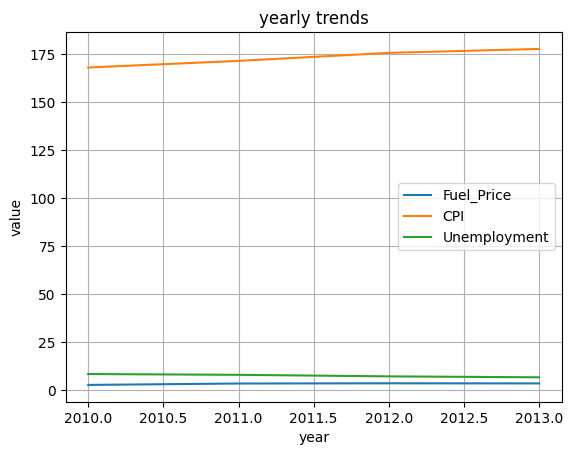

In [ ]:
# long-term trends: Yearly averages
df['Year'] = df['Date'].dt.year
yearly_trends = df.groupby('Year')[['Fuel_Price', 'CPI', 'Unemployment']].mean()
plt.figure(figsize=(10, 5))
yearly_trends.plot()
plt.title('yearly trends')
plt.xlabel('year')
plt.ylabel('value')
plt.legend()
plt.grid(True)
plt.show()

***Advanced Plots***

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
# Line Plot: Fuel_Price and Temperature over time
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(x=df['Date'], y=df['Fuel_Price'], name='Fuel_price', line=dict(color='orange')),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=df['Date'], y=df['Temperature'], name='Temperture Degree', line=dict(color='blue')),
    secondary_y=True,
)
fig.update_layout(
    title='time direction for temp and fuel_price',
    xaxis_title='date',
    yaxis_title='fuel_price',
    yaxis2_title='temp degree',
)
fig.show()


In [ ]:
# Line Plot: CPI and Unemployment over time
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(x=df['Date'], y=df['Unemployment'], name='Unemployment', line=dict(color='blue')),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=df['Date'], y=df['CPI'], name='CPI Degree', line=dict(color='red')),
    secondary_y=True,
)
fig.update_layout(
    title='time direction for CPI and Unemployment',
    xaxis_title='date',
    yaxis_title='Unemployment',
    yaxis2_title='CPI rate',
)
fig.show()


In [ ]:
# Bar Plot: Average MarkDown1 by IsHoliday
fig = px.bar(
    df.groupby('IsHoliday')['MarkDown1'].mean().reset_index(),
    x='IsHoliday',
    y='MarkDown1',
    title='Avg markdown due to Is Holiday',
    labels={'IsHoliday': 'Holiday', 'MarkDown1': 'AVG of first markdown'}
)
fig.show()


In [ ]:
# Scatter Plot: CPI vs Unemployment
fig = px.scatter(
    df,
    x='CPI',
    y='Unemployment',
    color='IsHoliday',
    title='Relation between CPI and employment',
    labels={'CPI': 'CPI', 'Unemployment': 'unemployment rate'}
)
fig.show()

**Data Analysis and Cleaning Report: Walmart Retail**

*1. Data Cleaning Steps*

    *1.1 Handling Missing Values*





**MarkDown1–5**: Missing values (50–64%) were imputed with 0, as NaN indicates no promotional discounts.



**CPI and Unemployment**: Missing values (7.1%) were imputed using forward-fill and backward-fill within each store to ensure continuity.



**Result**: No missing values remain in the dataset.

    1.2 Addressing Outliers





**MarkDown1–5**: Values exceeding 50,000 were investigated. Most were associated with holiday weeks (e.g., November), suggesting they are valid promotions. As a precaution, these values were capped at $50,000.



**Temperature**, **Fuel_Price**, **CPI**, **Unemployment**: Outliers (e.g., -2.06°F or 14.31% unemployment) were deemed realistic based on geographic and economic contexts and retained.

    1.3 Resolving Inconsistencies



**Date**: Verified to span from 2010-02-05 to 2013-07-26, with no invalid entries.



**Store**: Confirmed to contain expected values (1 to 45) with no duplicates or anomalies.

    1.4 Challenges





**MarkDown1–5 Outliers**: Distinguishing between genuine large promotions and potential errors was difficult without sales data for validation.



Imputation with 0 for MarkDown1–5: This approach may reduce variance but was the most logical choice given the context.

*2. Statistical Analysis*

    2.1 Correlations





**CPI** and **Unemployment**: A weak negative correlation (~-0.3) reflects economic dynamics where higher inflation often coincides with lower unemployment.



**MarkDown1–5**: Moderate positive correlations (~0.3–0.5) between some pairs (e.g., MarkDown1 and MarkDown2) suggest coordinated promotional strategies.



**Other Columns**: Weak correlations (close to 0) indicate relative independence among variables like *Temperature*, *Fuel_Price*, and others.

    2.2 Impact of Holidays





**Average values of MarkDown1–5** are significantly higher during holiday weeks (e.g., November/December), confirming holidays as a key driver of promotions.



Minimal differences observed in Temperature, Fuel_Price, CPI, and Unemployment between holiday and non-holiday weeks.

    2.3 Seasonality





**MarkDown1** peaks in November and December, aligning with major holidays (Thanksgiving, Christmas).



**Temperature** exhibits clear seasonality, with peaks in summer (July/August) and troughs in winter (January/February).

    2.4 Long-Term Trends





**Fuel_Price**: Upward trend from 2010 to 2012, reflecting rising oil prices.



**CPI**: Slow, steady increase, consistent with inflation.



**Unemployment**: Gradual decline, indicating economic recovery post-2008 recession.

3.* Insights*





**Holidays**: Major driver of promotional activity, necessitating strategic planning for holiday campaigns.



**Weather**: Seasonal temperature patterns influence customer behavior (e.g., increased demand for summer products in July).



**Economic Conditions**: Rising Fuel_Price and CPI may increase operational costs, while declining Unemployment could boost consumer spending.

4. *Recommendations*





Integrate sales data to validate the impact of promotions and weather on revenue.



Conduct store-specific analysis to uncover regional patterns in promotions and economic factors.



Develop predictive models to forecast future promotional activity based on holiday schedules and economic trends.

##  Forecasting Model Development and Optimization

> Add blockquote





In [ ]:
# Load datasets and  Merge datasets
train=pd.read_csv('/content/train.csv')
features=pd.read_csv('/content/features.csv')
test=pd.read_csv('/content/test.csv')
train_data= train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
test_data= test.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')




In [ ]:
# Convert date columns to datetime
for df in [train, test, features]:
    df['Date'] = pd.to_datetime(df['Date'])



In [ ]:
# Fill missing markdown values with 0
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
train_data[markdown_cols] = train_data[markdown_cols].fillna(0)
test_data[markdown_cols] = test_data[markdown_cols].fillna(0)

# Fill missing CPI and Unemployment values using forward fill
train_data[['CPI', 'Unemployment']] = train_data[['CPI', 'Unemployment']].ffill()
test_data[['CPI', 'Unemployment']] = test_data[['CPI', 'Unemployment']].ffill()

In [ ]:
# Extract date-related features
for df in [train_data, test_data]:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week


# Drop original Date
train_data.drop(['Date'], axis=1, inplace=True)
test_data.drop(['Date'], axis=1, inplace=True)



In [ ]:
train_data = pd.get_dummies(train_data, drop_first=True)
test_data = pd.get_dummies(test_data, drop_first=True)



In [ ]:
print(train_data.columns)
print(test_data.columns)


Index(['Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Year', 'Month', 'WeekOfYear', 'IsHoliday_True'],
      dtype='object')
Index(['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1',
       'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Year', 'Month', 'WeekOfYear'],
      dtype='object')


In [ ]:
# Define X and y for training
X = train_data.drop(['Weekly_Sales'], axis=1)
y = train_data['Weekly_Sales']

# Define test dataset for prediction
z_test = test_data.copy()


In [ ]:
# تقسيم البيانات
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
z_test = z_test.reindex(columns=x_train.columns, fill_value=0)

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
z_test_scaled = scaler.transform(z_test)

**bold text**## RandomForestRegressor model

In [ ]:
# Train the RandomForestRegressor model
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(x_train_scaled, y_train)


Fitting 3 folds for each of 24 candidates, totalling 72 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             verbose=2)

In [ ]:
y_pred = grid_search.predict(x_test_scaled)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("tuned hpyerparameters :(best parameters) ",grid_search.best_params_)
print("best_score_RF :",grid_search.best_score_)
print("mse_RF :",mse)
print("r2_RF :",r2)

tuned hpyerparameters :(best parameters)  {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
best_score_RF : 0.9542683701993081
mse_RF : 21696414.354058415
r2_RF : 0.9633688310472982


 Supoort vector regression model

### test

In [ ]:
test_preds =grid_search.predict(z_test)

# Preview predictions
print(test_preds[:10])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


[200845.5267   200845.5267   200845.5267   200845.5267   201220.52295
 201220.52295  201220.52295  201220.52295  200845.5267   170339.919325]


In [ ]:
# Prepare results in DataFrame format
predictions_table = pd.DataFrame({
    'Store': test_data['Store'],
    'Dept': test_data['Dept'],
    'Year': test_data['Year'],
    'Month': test_data['Month'],
    'WeekOfYear': test_data['WeekOfYear'],
    'IsHoliday': test_data['IsHoliday'],
    'Predicted_Weekly_Sales': test_preds
})

# Display the first 10 rows as a table
predictions_table.head(10)

,Store,Dept,Year,Month,WeekOfYear,IsHoliday,Predicted_Weekly_Sales
0,1,1,2012,11,44,False,200845.526700
1,1,1,2012,11,45,False,200845.526700
2,1,1,2012,11,46,False,200845.526700
3,1,1,2012,11,47,True,200845.526700
4,1,1,2012,11,48,False,201220.522950
5,1,1,2012,12,49,False,201220.522950
6,1,1,2012,12,50,False,201220.522950
7,1,1,2012,12,51,False,201220.522950
8,1,1,2012,12,52,True,200845.526700
9,1,1,2013,1,1,False,170339.919325


In [ ]:

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse_RF :",mse)
print("r2_RF :",r2)

mse_RF : 21696414.354058415
r2_RF : 0.9633688310472982
